In [33]:
import pandas as pd
import tensorflow.keras as keras
import seaborn as sns
import numpy as np
import os

In [34]:
train_df = pd.read_csv("/users/imbahndu/Desktop/Columbia DBM/PFED5/Annotations/train_41.csv")

In [35]:
train_df.head(10)

,videoID_subjectID,label,frame length,class,description
0,12-104704_0_001,4,63,0,sitting at rest
1,12-104704_1_001,2,73,1,smile
2,12-104704_2_001,1,75,2,frown
3,12-104704_3_001,1,112,3,squeeze eyes tightly
4,12-104704_4_001,2,90,4,clench the teeth
5,12-104705_0_001,3,61,0,sitting at rest
6,12-104705_1_001,1,65,1,smile
7,12-104705_2_001,1,99,2,frown
8,12-104705_3_001,0,94,3,squeeze eyes tightly
9,12-104705_4_001,2,75,4,clench the teeth


In [36]:
#Renaming the columns for consistency
train_df = train_df.rename(columns = {"label": "UPDRS_score", "class":"Task category"})

In [37]:
train_df

,videoID_subjectID,UPDRS_score,frame length,Task category,description
0,12-104704_0_001,4,63,0,sitting at rest
1,12-104704_1_001,2,73,1,smile
2,12-104704_2_001,1,75,2,frown
3,12-104704_3_001,1,112,3,squeeze eyes tightly
4,12-104704_4_001,2,90,4,clench the teeth
...,...,...,...,...,...
2042,16-002750_0_066,1,21,0,sitting at rest
2043,16-002750_1_066,3,73,1,smile
2044,16-002750_2_066,4,90,2,frown
2045,16-002750_3_066,4,113,3,squeeze eyes tightly


Joining dataframes with image 

In [38]:
train_df.head(100)

,videoID_subjectID,UPDRS_score,frame length,Task category,description
0,12-104704_0_001,4,63,0,sitting at rest
1,12-104704_1_001,2,73,1,smile
2,12-104704_2_001,1,75,2,frown
3,12-104704_3_001,1,112,3,squeeze eyes tightly
4,12-104704_4_001,2,90,4,clench the teeth
...,...,...,...,...,...
95,13-003195_0_007,0,29,0,sitting at rest
96,13-003195_1_007,0,31,1,smile
97,13-003195_2_007,0,38,2,frown
98,13-003195_3_007,0,54,3,squeeze eyes tightly


In [39]:

import glob

# 2. Extract the folder name from videoID_subjectID
def find_image_folder(video_id):
    # E.g. video_id = "12-104704_0_001" → folder = "12-104704_0"
    base_id = "_".join(video_id.split("_")[:2])
    search_pattern = os.path.join("frames", "*", base_id)
    matches = glob.glob(search_pattern)
    return matches[0] if matches else None

train_df['image_folder_path'] = train_df['videoID_subjectID'].apply(find_image_folder)

# 3. Collect image paths from the folder
def get_image_paths(folder_path):
    if folder_path and os.path.exists(folder_path):
        return sorted(glob.glob(os.path.join(folder_path, '*.jpg')))
    return []

train_df['image_paths'] = train_df['image_folder_path'].apply(get_image_paths)

# 4. Select a main frame (e.g., the middle frame)
def get_main_frame(images):
    return images[len(images)//2] if images else None

train_df['main_frame'] = train_df['image_paths'].apply(get_main_frame)

# 5. Optionally filter out rows with no images
train_df = train_df[train_df['image_paths'].map(len) > 0].reset_index(drop=True)

# Done! You can now use df['main_frame'] or df['image_paths'] to feed into your CNN.
print(train_df.head())


  videoID_subjectID  UPDRS_score  frame length  Task category  \
0   12-104704_0_001            4            63              0   
1   12-104704_1_001            2            73              1   
2   12-104704_2_001            1            75              2   
3   12-104704_3_001            1           112              3   
4   12-104704_4_001            2            90              4   

            description       image_folder_path  \
0       sitting at rest  frames/001/12-104704_0   
1                 smile  frames/001/12-104704_1   
2                 frown  frames/001/12-104704_2   
3  squeeze eyes tightly  frames/001/12-104704_3   
4      clench the teeth  frames/001/12-104704_4   

                                         image_paths  \
0  [frames/001/12-104704_0/img_00001.jpg, frames/...   
1  [frames/001/12-104704_1/img_00001.jpg, frames/...   
2  [frames/001/12-104704_2/img_00001.jpg, frames/...   
3  [frames/001/12-104704_3/img_00001.jpg, frames/...   
4  [frames/001/12-1047

In [40]:
train_df

,videoID_subjectID,UPDRS_score,frame length,Task category,description,image_folder_path,image_paths,main_frame
0,12-104704_0_001,4,63,0,sitting at rest,frames/001/12-104704_0,"[frames/001/12-104704_0/img_00001.jpg, frames/...",frames/001/12-104704_0/img_00032.jpg
1,12-104704_1_001,2,73,1,smile,frames/001/12-104704_1,"[frames/001/12-104704_1/img_00001.jpg, frames/...",frames/001/12-104704_1/img_00037.jpg
2,12-104704_2_001,1,75,2,frown,frames/001/12-104704_2,"[frames/001/12-104704_2/img_00001.jpg, frames/...",frames/001/12-104704_2/img_00038.jpg
3,12-104704_3_001,1,112,3,squeeze eyes tightly,frames/001/12-104704_3,"[frames/001/12-104704_3/img_00001.jpg, frames/...",frames/001/12-104704_3/img_00057.jpg
4,12-104704_4_001,2,90,4,clench the teeth,frames/001/12-104704_4,"[frames/001/12-104704_4/img_00001.jpg, frames/...",frames/001/12-104704_4/img_00046.jpg
...,...,...,...,...,...,...,...,...
2042,16-002750_0_066,1,21,0,sitting at rest,frames/066/16-002750_0,"[frames/066/16-002750_0/img_00001.jpg, frames/...",frames/066/16-002750_0/img_00011.jpg
2043,16-002750_1_066,3,73,1,smile,frames/066/16-002750_1,"[frames/066/16-002750_1/img_00001.jpg, frames/...",frames/066/16-002750_1/img_00037.jpg
2044,16-002750_2_066,4,90,2,frown,frames/066/16-002750_2,"[frames/066/16-002750_2/img_00001.jpg, frames/...",frames/066/16-002750_2/img_00046.jpg
2045,16-002750_3_066,4,113,3,squeeze eyes tightly,frames/066/16-002750_3,"[frames/066/16-002750_3/img_00001.jpg, frames/...",frames/066/16-002750_3/img_00057.jpg


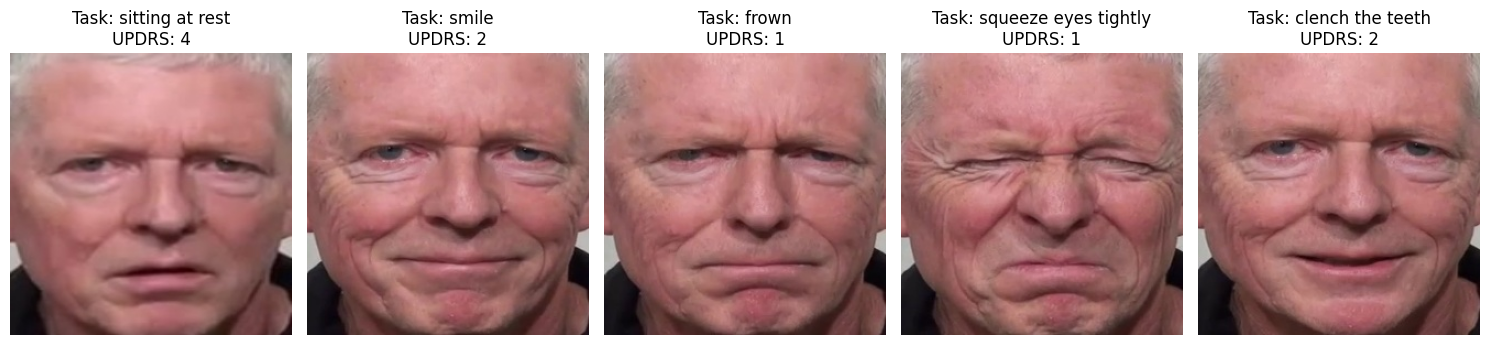

In [41]:
import pandas as pd
import matplotlib.pyplot as plt
from PIL import Image


# Filter only rows with valid main_frame entries
valid_rows = train_df[train_df['main_frame'].notnull()].head(5)  # Display first 5 with images

plt.figure(figsize=(15,5))

for i, (_, row) in enumerate(valid_rows.iterrows()):
    try:
        img = Image.open(row['main_frame'])
        plt.subplot(1, 5, i + 1)
        plt.imshow(img)
        plt.axis('off')
        plt.title(f"Task: {row['description']}\nUPDRS: {row['UPDRS_score']}")
    except Exception as e:
        print(f"Failed to load image at {row['main_frame']}: {e}")

plt.tight_layout()
plt.show()


In [42]:
#Checking to see if there are nulls
train_df.isnull().sum()

videoID_subjectID    0
UPDRS_score          0
frame length         0
Task category        0
description          0
image_folder_path    0
image_paths          0
main_frame           0
dtype: int64

In [43]:
#Checking datatypes 
for col in train_df.columns:
    print(col, ' ', train_df[col].dtype)


videoID_subjectID   object
UPDRS_score   int64
frame length   int64
Task category   int64
description   object
image_folder_path   object
image_paths   object
main_frame   object


In [44]:
#Dropping out irrelevant columns that might not be predictive of the model 

train_df = train_df.drop(columns = ['videoID_subjectID', 'frame length', 'Task category', "image_folder_path", "image_paths"])

In [45]:
train_df

,UPDRS_score,description,main_frame
0,4,sitting at rest,frames/001/12-104704_0/img_00032.jpg
1,2,smile,frames/001/12-104704_1/img_00037.jpg
2,1,frown,frames/001/12-104704_2/img_00038.jpg
3,1,squeeze eyes tightly,frames/001/12-104704_3/img_00057.jpg
4,2,clench the teeth,frames/001/12-104704_4/img_00046.jpg
...,...,...,...
2042,1,sitting at rest,frames/066/16-002750_0/img_00011.jpg
2043,3,smile,frames/066/16-002750_1/img_00037.jpg
2044,4,frown,frames/066/16-002750_2/img_00046.jpg
2045,4,squeeze eyes tightly,frames/066/16-002750_3/img_00057.jpg


In [46]:
#One hot encode categorical variables

train_df = pd.get_dummies(train_df, columns = ["description"], dtype = float)

train_df

,UPDRS_score,main_frame,description_clench the teeth,description_frown,description_sitting at rest,description_smile,description_squeeze eyes tightly
0,4,frames/001/12-104704_0/img_00032.jpg,0.0,0.0,1.0,0.0,0.0
1,2,frames/001/12-104704_1/img_00037.jpg,0.0,0.0,0.0,1.0,0.0
2,1,frames/001/12-104704_2/img_00038.jpg,0.0,1.0,0.0,0.0,0.0
3,1,frames/001/12-104704_3/img_00057.jpg,0.0,0.0,0.0,0.0,1.0
4,2,frames/001/12-104704_4/img_00046.jpg,1.0,0.0,0.0,0.0,0.0
...,...,...,...,...,...,...,...
2042,1,frames/066/16-002750_0/img_00011.jpg,0.0,0.0,1.0,0.0,0.0
2043,3,frames/066/16-002750_1/img_00037.jpg,0.0,0.0,0.0,1.0,0.0
2044,4,frames/066/16-002750_2/img_00046.jpg,0.0,1.0,0.0,0.0,0.0
2045,4,frames/066/16-002750_3/img_00057.jpg,0.0,0.0,0.0,0.0,1.0


In [47]:
train_df.to_csv("train_cnn.csv", index=False)